# CSC3042F Assignment 1: MLP vs CNN

**Name:** Timera Govender

**Course:** CSC3042F AI: Deep Learning

**Assignment:** Assignment 1 - MLP vs CNN - Architecture, Efficiency, and Inductive Bias

This notebook investigates the performance of Multi-Layer Perceptrons and Convolutional Neural Networks on MNIST and CIFAR-10. 

## Academic Integrity and Tool Use Declaration

This assignment was completed individually. AI assistance was used only for conceptual clarification, debugging support, planning the notebook structure, and improving grammar. The experimental design, implementation, results, and analysis were completed and verified by me.

No trained model weights are included in this submission. All models are trained from scratch when the notebook is run. 

## Notebook Roadmap

This notebook is organised as follows:

1. Global Setup
2. Dataset loading and preprocessing
3. Helper functions
4. Part A: Complexity Ladder experiments
    - A4.1. Implementation
    - A4.2. Results table
    - A4.3. Training and Validation Curves
    - A4.4. Analysis
    - A4.5. MLP Performance Drop on CIFAR-10
5. Part B: The Parameter Budget Challenge
    - B4.1. Architecture report
    - B4.2. Hyperparameter Search
    - B4.3. Training
    - B4.4. Efficiency Analysis
    - B4.5. Reflection
6. Final Reproducibility Checklist

# 1. Global Setup

This section imports the required libraries, sets all random seeds for reproducibility, and selects the available hardware device.

In [1]:
# Standard library imports
import random
import time

# Scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

%matplotlib inline

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


# 2. Dataset Loading and Preprocessing

The assignment uses MNIST and CIFAR-10 through `torchvision.datasets`. The standard training and test splits are used. The original training set is further split into 80% training and 20% validation.

MNIST images are resized from 28×28 to 32×32 so that both MNIST and CIFAR-10 have the same spatial dimensions. This keeps the core architectures consistent across datasets, as required.

In [2]:
# Defining temporary transforms

BATCH_SIZE = 64

mnist_temp_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
]) 

cifar10_temp_transform = transforms.Compose([
    transforms.ToTensor()
])

# Loading the train and test datasets with the temporary transforms

mnist_train_temp = datasets.MNIST(
    root = "./data",
    train = True,
    download = True,
    transform = mnist_temp_transform
)

cifar10_train_temp = datasets.CIFAR10(
    root = "./data",
    train = True,
    download = True,
    transform = cifar10_temp_transform
)

# Checkpoint:

print("MNIST training examples:", len(mnist_train_temp))
print("CIFAR-10 training examples:", len(cifar10_train_temp))
print("")

# Finding the mean and standard deviations for the training datasets

def compute_mean_std(dataset, batch_size = BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    channel_sum = 0.0
    channel_squared_sum = 0.0
    num_pixels = 0

    for images, _ in loader:
        # image shape [batch_size, channels, height, width]
        batch_size_current, channels, height, width = images.shape

        # Sum over batch, height, and width (one value per channel)
        channel_sum += images.sum(dim=[0, 2, 3])
        channel_squared_sum += (images ** 2).sum(dim=[0, 2, 3]) 

        # Number of pixels per channel in this batch
        num_pixels += batch_size_current * height * width

    mean = channel_sum / num_pixels
    std = torch.sqrt((channel_squared_sum / num_pixels) - (mean ** 2))

    return mean, std

mnist_mean, mnist_std = compute_mean_std(mnist_train_temp, BATCH_SIZE)
cifar10_mean, cifar10_std = compute_mean_std(cifar10_train_temp, BATCH_SIZE)

# Checkpoint:

print("MNIST mean:", mnist_mean)
print("MNIST std:", mnist_std)

print("")

print("CIFAR-10 mean:", cifar10_mean)
print("CIFAR-10 std:", cifar10_std)

100.0%
100.0%
100.0%
100.0%
100.0%


MNIST training examples: 60000
CIFAR-10 training examples: 50000

MNIST mean: tensor([0.1309])
MNIST std: tensor([0.2893])

CIFAR-10 mean: tensor([0.4914, 0.4822, 0.4465])
CIFAR-10 std: tensor([0.2470, 0.2435, 0.2616])


In [3]:
# Defining the final transforms using the mean and std deviation

mnist_mean_tuple = tuple(mnist_mean.tolist())
mnist_std_tuple = tuple(mnist_std.tolist())

cifar10_mean_tuple = tuple(cifar10_mean.tolist())
cifar10_std_tuple = tuple(cifar10_std.tolist())

mnist_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean_tuple, mnist_std_tuple)
])

cifar10_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean_tuple, cifar10_std_tuple)
])

# Reloading the train and test datasets with the final transforms

mnist_full_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform
)

mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)

cifar10_full_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cifar10_transform
)

cifar10_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=cifar10_transform
)

In [4]:
# Split each training set into 80% training and 20% validation

mnist_train_size = int(0.8 * len(mnist_full_train))
mnist_val_size = len(mnist_full_train) - mnist_train_size

cifar10_train_size = int(0.8 * len(cifar10_full_train))
cifar10_val_size = len(cifar10_full_train) - cifar10_train_size

mnist_generator = torch.Generator().manual_seed(SEED)
cifar10_generator = torch.Generator().manual_seed(SEED)

mnist_train, mnist_val = random_split(
    mnist_full_train,
    [mnist_train_size, mnist_val_size],
    generator=mnist_generator
)

cifar10_train, cifar10_val = random_split(
    cifar10_full_train,
    [cifar10_train_size, cifar10_val_size],
    generator=cifar10_generator
)

# Checkpoint:

print("MNIST train size:", len(mnist_train))
print("MNIST validation size:", len(mnist_val))
print("MNIST test size:", len(mnist_test))

print("")

print("CIFAR-10 train size:", len(cifar10_train))
print("CIFAR-10 validation size:", len(cifar10_val))
print("CIFAR-10 test size:", len(cifar10_test))

MNIST train size: 48000
MNIST validation size: 12000
MNIST test size: 10000

CIFAR-10 train size: 40000
CIFAR-10 validation size: 10000
CIFAR-10 test size: 10000


In [5]:
# Creating the DataLoaders

mnist_train_loader = DataLoader(
    mnist_train,
    batch_size= BATCH_SIZE,
    shuffle= True
)

mnist_val_loader = DataLoader(
    mnist_val,
    batch_size= BATCH_SIZE,
    shuffle= False
)

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size= BATCH_SIZE,
    shuffle = False
)

cifar10_train_loader = DataLoader(
    cifar10_train,
    batch_size= BATCH_SIZE,
    shuffle= True
)

cifar10_val_loader = DataLoader(
    cifar10_val,
    batch_size= BATCH_SIZE,
    shuffle = False
)

cifar10_test_loader = DataLoader(
    cifar10_test,
    batch_size= BATCH_SIZE,
    shuffle = False
)

# Checkpoint: dataset sizes

print("MNIST train size:", len(mnist_train))
print("MNIST validation size:", len(mnist_val))
print("MNIST test size:", len(mnist_test))
print("")
print("CIFAR-10 train size:", len(cifar10_train))
print("CIFAR-10 validation size:", len(cifar10_val))
print("CIFAR-10 test size:", len(cifar10_test))
print("")

# Checkpoint: Batch shapes

mnist_images, mnist_labels = next(iter(mnist_train_loader))
cifar10_images, cifar10_labels = next(iter(cifar10_train_loader))

print("MNIST image batch shape:", mnist_images.shape)
print("MNIST label batch shape:", mnist_labels.shape)
print("")

print("CIFAR-10 image batch shape:", cifar10_images.shape)
print("CIFAR-10 label batch shape:", cifar10_labels.shape)

MNIST train size: 48000
MNIST validation size: 12000
MNIST test size: 10000

CIFAR-10 train size: 40000
CIFAR-10 validation size: 10000
CIFAR-10 test size: 10000

MNIST image batch shape: torch.Size([64, 1, 32, 32])
MNIST label batch shape: torch.Size([64])

CIFAR-10 image batch shape: torch.Size([64, 3, 32, 32])
CIFAR-10 label batch shape: torch.Size([64])


The above batch shapes confirm that MNIST inputs are loaded as 1×32×32 tensors and CIFAR-10 inputs are loaded as 3×32×32 tensors. Both datasets therefore share the same spatial resolution, while differing only in the number of input channels.

# 3. Helper Functions

This section defines reusable helper functions for parameter counting, training, evaluation, timing, plotting, and layer-wise parameter reporting. These functions are used consistently across Part A and Part B.

In [6]:
# Function to count the number of parameters in any given model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [7]:
# Function that evaluates a model on a specific dataset and outputting the loss and accuracy
def evaluate(model, dataloader, criterion, device):
    model.eval() # set the model to evaluation mode

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # no gradients are needed for validation/testing
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track loss
            running_loss += loss.item() * images.size(0)

            # Track accuracy
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [8]:
# Function to train a model on a specific dataset for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set model to training mode

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update Parameters
        optimizer.step()

        # Track loss
        running_loss += loss.item() * images.size(0)

        # Track accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [9]:
# Functions that trains a model using train_one_epoch(...)
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    model = model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_times": []
    }

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        end_time = time.time()
        epoch_time = end_time - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_times"].append(epoch_time)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_acc * 100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_acc * 100:.2f}% | "
            f"Time: {epoch_time:.2f}s"
        )
    
    return history

In [10]:
# Function to test a model that has been trained
def test_model(model, test_loader, criterion, device):
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")

    return test_loss, test_acc

In [11]:
# Function used to generate Loss curves for both Architectures
def plot_loss_curves(mlp_history, cnn_history, dataset_name):
    epochs = range(1, len(mlp_history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(epochs, mlp_history["train_loss"], label="MLP Train Loss")
    plt.plot(epochs, mlp_history["val_loss"], label="MLP Validation Loss")
    plt.plot(epochs, cnn_history["train_loss"], label="CNN Train Loss")
    plt.plot(epochs, cnn_history["val_loss"], label="CNN Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{dataset_name}: Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
# Function used to generate Accuracy curves for both architectures
def plot_accuracy_curves(mlp_history, cnn_history, dataset_name):
    epochs = range(1, len(mlp_history["train_acc"]) + 1)

    mlp_train_acc = [acc * 100 for acc in mlp_history["train_acc"]]
    mlp_val_acc = [acc * 100 for acc in mlp_history["val_acc"]]
    cnn_train_acc = [acc * 100 for acc in cnn_history["train_acc"]]
    cnn_val_acc = [acc * 100 for acc in cnn_history["val_acc"]]

    plt.figure(figsize=(8, 5))

    plt.plot(epochs, mlp_train_acc, label="MLP Train Accuracy")
    plt.plot(epochs, mlp_val_acc, label="MLP Validation Accuracy")
    plt.plot(epochs, cnn_train_acc, label="CNN Train Accuracy")
    plt.plot(epochs, cnn_val_acc, label="CNN Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{dataset_name}: Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [13]:
# Function that creates a detailed breakdown of parameters in a given model
def parameter_table(model):
    rows = []

    for name, parameter in model.named_parameters():
        if parameter.requires_grad:
            rows.append({
                "Layer": name,
                "Shape": list(parameter.shape),
                "Parameters": parameter.numel()
            })

    table = pd.DataFrame(rows)

    total_params = table["Parameters"].sum()
    total_row = pd.DataFrame([{
        "Layer": "Total",
        "Shape": "",
        "Parameters": total_params
    }])

    table = pd.concat([table, total_row], ignore_index=True)

    return table

# 4. Part A: The Complexity Ladder (27 Marks)

In Part A, a fixed MLP and a fixed CNN are trained on MNIST and CIFAR-10. The same core architecture is used across datasets, with only the input dimensionality or number of input channels changed where necessary.

## A4.1. - Implementation: Clean, commented code for both architectures and the training loop.

For the MLP, images are flattened before being passed through a fixed sequence of fully connected hidden layers. The same hidden-layer structure is used for both MNIST and CIFAR-10.

For the CNN, the model uses a fixed sequence of convolutional blocks followed by a fully connected classifier. The same number of convolutional blocks, filter sizes, kernel sizes, pooling operations, and fully connected layers are used across both datasets. Only the number of input channels differs between MNIST and CIFAR-10.

MNIST is resized to 32×32 so that the spatial input size is consistent with CIFAR-10.

### MLP

In [14]:
class PartAMLP(nn.Module):
    def __init__(self, input_dim, num_classes=10, dropout_rate=0.2):
        super(PartAMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, 512),
            nn.ReLU(), # Adds non-linearity so the MLP can learn complex patterns
            nn.Dropout(dropout_rate),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)
    
mnist_mlp = PartAMLP(input_dim=1 * 32 * 32)
cifar10_mlp = PartAMLP(input_dim=3 * 32 * 32)

print("MNIST MLP parameters:", count_parameters(mnist_mlp))
print("CIFAR-10 MLP parameters:", count_parameters(cifar10_mlp))

MNIST MLP parameters: 697930
CIFAR-10 MLP parameters: 1746506


### CNN

In [15]:
class PartACNN(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super(PartACNN, self).__init__()

        self.features = nn.Sequential(
            # Conv block 1: 32x32 -> 16x16
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Conv block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv block 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

mnist_cnn = PartACNN(in_channels=1)
cifar10_cnn = PartACNN(in_channels=3)

print("MNIST CNN parameters:", count_parameters(mnist_cnn))
print("CIFAR-10 CNN parameters:", count_parameters(cifar10_cnn))

MNIST CNN parameters: 356234
CIFAR-10 CNN parameters: 356810


### Part A Training

The following experiments are trained:

1. MLP on MNIST
2. CNN on MNIST
3. MLP on CIFAR-10
4. CNN on CIFAR-10

For each experiment, the training loss, validation loss, training accuracy, validation accuracy, test accuracy, and seconds per epoch are recorded.

In [16]:
# Hyperparameters:
PART_A_EPOCHS = 15
PART_A_LR = 0.001

# Loss Function
criterion = nn.CrossEntropyLoss()

# Move models to the same device:
mnist_mlp = mnist_mlp.to(device)
mnist_cnn = mnist_cnn.to(device)
cifar10_mlp = cifar10_mlp.to(device)
cifar10_cnn = cifar10_cnn.to(device)

# Creating optimizers:
mnist_mlp_optimizer = optim.Adam(mnist_mlp.parameters(), lr=PART_A_LR)
mnist_cnn_optimizer = optim.Adam(mnist_cnn.parameters(), lr=PART_A_LR)

cifar10_mlp_optimizer = optim.Adam(cifar10_mlp.parameters(), lr=PART_A_LR)
cifar10_cnn_optimizer = optim.Adam(cifar10_cnn.parameters(), lr=PART_A_LR)

In [17]:
# Training the Models

print("Training MNIST MLP")
mnist_mlp_history = train_model(
    mnist_mlp,
    mnist_train_loader,
    mnist_val_loader,
    criterion,
    mnist_mlp_optimizer,
    PART_A_EPOCHS,
    device
)

print("\nTraining MNIST CNN")
mnist_cnn_history = train_model(
    mnist_cnn,
    mnist_train_loader,
    mnist_val_loader,
    criterion,
    mnist_cnn_optimizer,
    PART_A_EPOCHS,
    device
)

print("\nTraining CIFAR-10 MLP")
cifar10_mlp_history = train_model(
    cifar10_mlp,
    cifar10_train_loader,
    cifar10_val_loader,
    criterion,
    cifar10_mlp_optimizer,
    PART_A_EPOCHS,
    device
)

print("\nTraining CIFAR-10 CNN")
cifar10_cnn_history = train_model(
    cifar10_cnn,
    cifar10_train_loader,
    cifar10_val_loader,
    criterion,
    cifar10_cnn_optimizer,
    PART_A_EPOCHS,
    device
)

Training MNIST MLP
Epoch [1/15] Train Loss: 0.3257 | Train Accuracy: 89.85% | Val Loss: 0.1534 | Val Accuracy: 95.53% | Time: 17.94s
Epoch [2/15] Train Loss: 0.1524 | Train Accuracy: 95.56% | Val Loss: 0.1192 | Val Accuracy: 96.58% | Time: 17.02s
Epoch [3/15] Train Loss: 0.1172 | Train Accuracy: 96.55% | Val Loss: 0.1112 | Val Accuracy: 97.02% | Time: 20.31s
Epoch [4/15] Train Loss: 0.1007 | Train Accuracy: 97.05% | Val Loss: 0.1026 | Val Accuracy: 97.25% | Time: 19.64s
Epoch [5/15] Train Loss: 0.0875 | Train Accuracy: 97.37% | Val Loss: 0.1009 | Val Accuracy: 97.44% | Time: 19.62s
Epoch [6/15] Train Loss: 0.0769 | Train Accuracy: 97.74% | Val Loss: 0.0947 | Val Accuracy: 97.66% | Time: 19.57s
Epoch [7/15] Train Loss: 0.0699 | Train Accuracy: 97.94% | Val Loss: 0.0901 | Val Accuracy: 97.69% | Time: 19.90s
Epoch [8/15] Train Loss: 0.0653 | Train Accuracy: 98.08% | Val Loss: 0.0992 | Val Accuracy: 97.52% | Time: 19.79s
Epoch [9/15] Train Loss: 0.0609 | Train Accuracy: 98.19% | Val Loss: 

In [18]:
# Testing the models

print("MNIST MLP Test Results")
mnist_mlp_test_loss, mnist_mlp_test_acc = test_model(
    mnist_mlp,
    mnist_test_loader,
    criterion,
    device
)

print("\nMNIST CNN Test Results")
mnist_cnn_test_loss, mnist_cnn_test_acc = test_model(
    mnist_cnn,
    mnist_test_loader,
    criterion,
    device
)

print("\nCIFAR-10 MLP Test Results")
cifar10_mlp_test_loss, cifar10_mlp_test_acc = test_model(
    cifar10_mlp,
    cifar10_test_loader,
    criterion,
    device
)

print("\nCIFAR-10 CNN Test Results")
cifar10_cnn_test_loss, cifar10_cnn_test_acc = test_model(
    cifar10_cnn,
    cifar10_test_loader,
    criterion,
    device
)

MNIST MLP Test Results
Test Loss: 0.0809
Test Accuracy: 98.18%

MNIST CNN Test Results
Test Loss: 0.0331
Test Accuracy: 99.24%

CIFAR-10 MLP Test Results
Test Loss: 1.3524
Test Accuracy: 53.65%

CIFAR-10 CNN Test Results
Test Loss: 1.5976
Test Accuracy: 72.29%


## A4.2. - Results Table

The table below reports the final test loss, test accuracy, parameter count, total training time, and average seconds per epoch for each Part A experiment. The same optimiser, learning rate, batch size, and number of epochs were used across all Part A experiments to keep the architecture comparison controlled.

In [19]:
# Function to get the average training time per epoch and the total training time for the model
def get_training_time(history):
    total_time = sum(history["epoch_times"])
    seconds_per_epoch = total_time / len(history["epoch_times"])
    return total_time, seconds_per_epoch

mnist_mlp_total_time, mnist_mlp_sec_per_epoch = get_training_time(mnist_mlp_history)
mnist_cnn_total_time, mnist_cnn_sec_per_epoch = get_training_time(mnist_cnn_history)

cifar10_mlp_total_time, cifar10_mlp_sec_per_epoch = get_training_time(cifar10_mlp_history)
cifar10_cnn_total_time, cifar10_cnn_sec_per_epoch = get_training_time(cifar10_cnn_history)

part_a_results = pd.DataFrame([
    {
        "Dataset": "MNIST",
        "Model": "MLP",
        "Parameters": count_parameters(mnist_mlp),
        "Test Loss": mnist_mlp_test_loss,
        "Test Accuracy (%)": mnist_mlp_test_acc * 100,
        "Total Training Time (s)": mnist_mlp_total_time,
        "Seconds per Epoch": mnist_mlp_sec_per_epoch
    },
    {
        "Dataset": "MNIST",
        "Model": "CNN",
        "Parameters": count_parameters(mnist_cnn),
        "Test Loss": mnist_cnn_test_loss,
        "Test Accuracy (%)": mnist_cnn_test_acc * 100,
        "Total Training Time (s)": mnist_cnn_total_time,
        "Seconds per Epoch": mnist_cnn_sec_per_epoch
    },
    {
        "Dataset": "CIFAR-10",
        "Model": "MLP",
        "Parameters": count_parameters(cifar10_mlp),
        "Test Loss": cifar10_mlp_test_loss,
        "Test Accuracy (%)": cifar10_mlp_test_acc * 100,
        "Total Training Time (s)": cifar10_mlp_total_time,
        "Seconds per Epoch": cifar10_mlp_sec_per_epoch
    },
    {
        "Dataset": "CIFAR-10",
        "Model": "CNN",
        "Parameters": count_parameters(cifar10_cnn),
        "Test Loss": cifar10_cnn_test_loss,
        "Test Accuracy (%)": cifar10_cnn_test_acc * 100,
        "Total Training Time (s)": cifar10_cnn_total_time,
        "Seconds per Epoch": cifar10_cnn_sec_per_epoch
    }
])

part_a_results

,Dataset,Model,Parameters,Test Loss,Test Accuracy (%),Total Training Time (s),Seconds per Epoch
0,MNIST,MLP,697930,0.080876,98.18,301.970691,20.131379
1,MNIST,CNN,356234,0.033148,99.24,896.480641,59.765376
2,CIFAR-10,MLP,1746506,1.352362,53.65,310.058289,20.670553
3,CIFAR-10,CNN,356810,1.597627,72.29,765.491335,51.032756


## A4.3. Part A Training and Validation Curves

The following plots show the training and validation loss/accuracy curves for the MLP and CNN on MNIST and CIFAR-10. These curves are used to compare both final performance and generalisation behaviour across the two architectures.


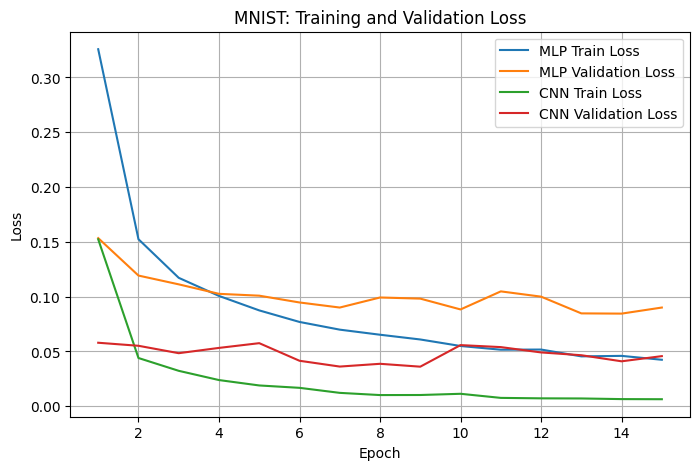

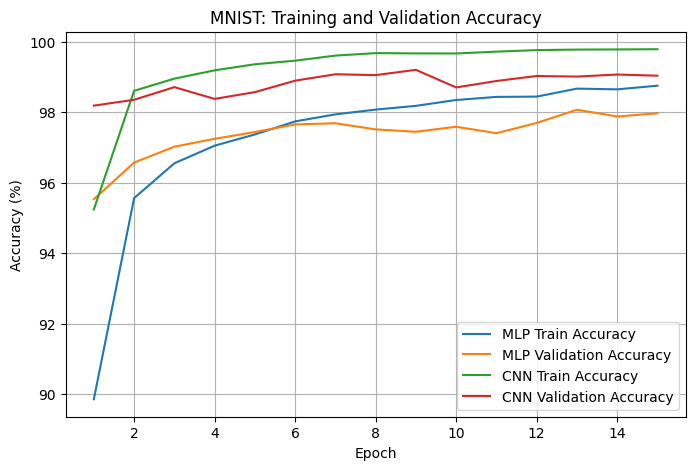

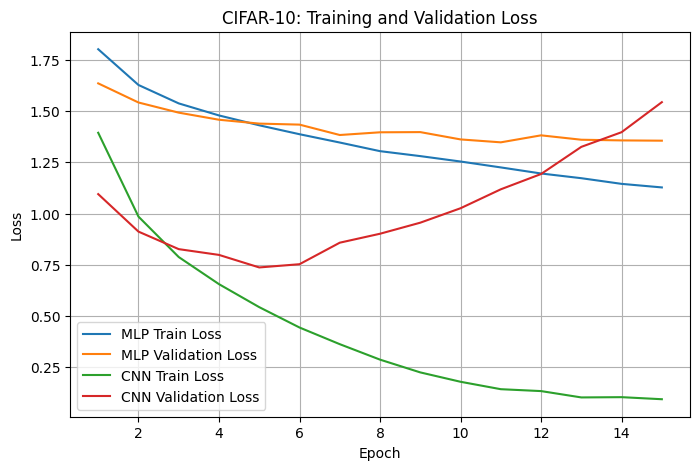

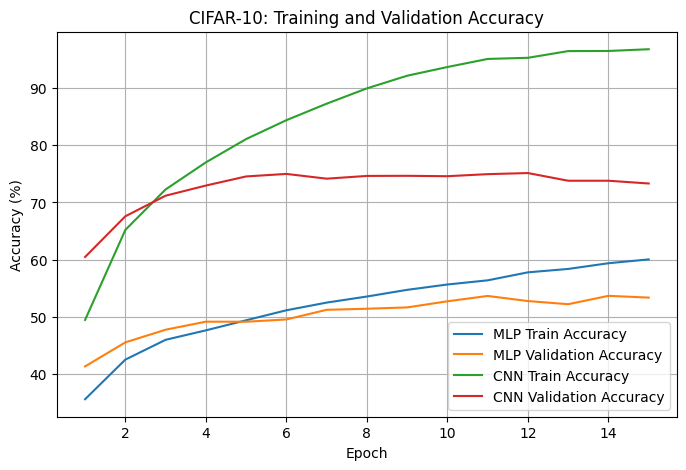

In [20]:
# Training and Validation Curves

plot_loss_curves(
    mnist_mlp_history,
    mnist_cnn_history,
    "MNIST"
)

plot_accuracy_curves(
    mnist_mlp_history,
    mnist_cnn_history,
    "MNIST"
)

plot_loss_curves(
    cifar10_mlp_history,
    cifar10_cnn_history,
    "CIFAR-10"
)

plot_accuracy_curves(
    cifar10_mlp_history,
    cifar10_cnn_history,
    "CIFAR-10"
)

## A4.4. Part A Analysis

The CNN outperformed the MLP on both datasets, but the size of the gap depended strongly on dataset complexity. On MNIST, both models performed well: the MLP achieved 98.18% test accuracy, while the CNN achieved 99.24%, a difference of only 1.06 percentage points. This small gap is expected because MNIST contains simple, centred, grayscale digit images with little background clutter, so even a flattened representation is informative.

However, the performance gap increased clearly on CIFAR-10. The MLP achieved 53.65% test accuracy, while the CNN achieved 72.29%, giving the CNN an 18.64 percentage point advantage. The training curves support this as the CIFAR-10 MLP’s validation accuracy plateaued around 52–54%, while the CNN reached a peak validation accuracy of 75.12%. The CNN also showed stronger overfitting, since its training accuracy rose to 96.73% while validation loss increased after epoch 5, suggesting it learned powerful training features but began to generalise less effectively later.

The key architectural advantage of CNNs is their convolutional structure. CNNs preserve spatial locality by learning local filters over neighbouring pixels, while the MLP flattens images into unstructured vectors and loses explicit 2D neighbourhood information. Weight sharing allows the same feature detector to be applied across different image regions, making CNNs more robust to changes in object position. This gives CNNs a degree of translation-aware feature detection: if an edge, texture, or object part appears in a different location, the same convolutional filter can still detect it. Together, these properties give CNNs a stronger inductive bias for image data; they assume that local patterns such as edges, textures, and object parts are meaningful and reusable.

## A4.5. Part A Reflection: MLP Performance Drop on CIFAR-10

The MLP’s accuracy drops most sharply on CIFAR-10. On MNIST, the MLP achieved 98.18% test accuracy, but on CIFAR-10 it achieved only 53.65%. This is a drop of 44.53 percentage points. The property most responsible for this drop is CIFAR-10’s complex spatial structure: objects are made up of local edges, textures, colours, and parts that appear in different positions and against varied backgrounds.

This affects the MLP because it flattens each image into a one-dimensional vector before classification. Flattening removes the explicit 2D neighbourhood relationships between pixels, so spatially adjacent pixels are not represented as local neighbours. This is less harmful for MNIST because the digits are centred, grayscale, and visually simple. However, in CIFAR-10, class identity depends much more on local spatial correlations and object-part arrangements. Therefore, the MLP struggles to generalise because it must learn these spatial relationships from scratch using fully connected layers.

# 5. Part B: The Parameter Budget Challenge

Part B compares a redesigned MLP and CNN on CIFAR-10 under an approximately equal parameter budget. Both models are constrained to have between 475,000 and 525,000 trainable parameters.

## B4.1. Part B Architecture Report

The Part B models are redesigned specifically for CIFAR-10 under the fixed parameter budget. The objective is to compare how useful approximately equal numbers of parameters are in an MLP versus a CNN.

The MLP uses dense layers after flattening the CIFAR-10 image. The CNN uses convolutional feature extraction followed by a classifier head. The parameter counts are verified before training.

### MLP

In [21]:
class BudgetMLP(nn.Module):
    def __init__(self, input_dim=3 * 32 * 32, num_classes=10, dropout_rate=0.3):
        super(BudgetMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, 132),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(132, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)
    

### CNN

In [22]:
class BudgetCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, dropout_rate=0.3):
        super(BudgetCNN, self).__init__()

        self.features = nn.Sequential(
            # Conv block 1: 32x32 -> 16x16
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv block 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 192),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(192, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [23]:
# Layer-by-layer parameter count table for BudgetMLP.
budget_mlp = BudgetMLP(dropout_rate=0.3)

print("Budget MLP parameters:", count_parameters(budget_mlp))
display(parameter_table(budget_mlp))
print("")

# Layer-by-layer parameter count table for BudgetCNN.
budget_cnn = BudgetCNN(dropout_rate=0.3)

print("Budget CNN parameters:", count_parameters(budget_cnn))
display(parameter_table(budget_cnn))

Budget MLP parameters: 481486


,Layer,Shape,Parameters
0,network.1.weight,"[132, 3072]",405504
1,network.1.bias,[132],132
2,network.4.weight,"[256, 132]",33792
3,network.4.bias,[256],256
4,network.7.weight,"[128, 256]",32768
5,network.7.bias,[128],128
6,network.10.weight,"[64, 128]",8192
7,network.10.bias,[64],64
8,network.13.weight,"[10, 64]",640
9,network.13.bias,[10],10



Budget CNN parameters: 488586


,Layer,Shape,Parameters
0,features.0.weight,"[32, 3, 3, 3]",864
1,features.0.bias,[32],32
2,features.3.weight,"[64, 32, 3, 3]",18432
3,features.3.bias,[64],64
4,features.6.weight,"[128, 64, 3, 3]",73728
5,features.6.bias,[128],128
6,classifier.1.weight,"[192, 2048]",393216
7,classifier.1.bias,[192],192
8,classifier.4.weight,"[10, 192]",1920
9,classifier.4.bias,[10],10


The Budget MLP has 481,486 trainable parameters, which falls within the required 475,000–525,000 parameter budget.

The Budget CNN has 488,586 trainable parameters, which falls within the required 475,000–525,000 parameter budget. Most of its parameters are in the final fully connected classifier, while the convolutional layers use comparatively fewer parameters to learn reusable spatial feature detectors.

## B4.2. Part B Hyperparameter Search

A small grid search was performed over two hyperparameters: learning rate and dropout rate. Each configuration was trained for 15 epochs on CIFAR-10 using the training set, and the best configuration was selected based primarily on validation accuracy, with validation loss used as a secondary criterion.

In [24]:
# Hyperparameter Search Settings

learning_rates = [0.001, 0.0005]
dropout_rates = [0.3, 0.5]

PART_B_SEARCH_EPOCHS = 15
PART_B_FINAL_EPOCHS = 30

best_mlp_lr = 0.0005
best_mlp_dropout = 0.3

criterion = nn.CrossEntropyLoss()

# Search function

def run_hyperparameter_search(model_class, model_name, learning_rates, dropout_rates, train_loader, val_loader, criterion, device):
    search_results = []

    for lr in learning_rates:
        for dropout in dropout_rates:
            print(f"\nTraining {model_name} | LR={lr} | Dropout={dropout}")

            # Create a fresh model for each configuration
            model = model_class(dropout_rate=dropout).to(device)

            optimizer = optim.Adam(model.parameters(), lr=lr)

            history = train_model(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                criterion=criterion,
                optimizer=optimizer,
                epochs=PART_B_SEARCH_EPOCHS,
                device=device
            )

            final_val_loss = history["val_loss"][-1]
            final_val_acc = history["val_acc"][-1]
            total_time = sum(history["epoch_times"])
            seconds_per_epoch = total_time / len(history["epoch_times"])

            search_results.append({
                "Model": model_name,
                "Learning Rate": lr,
                "Dropout": dropout,
                "Final Val Loss": final_val_loss,
                "Final Val Accuracy (%)": final_val_acc * 100,
                "Total Search Time (s)": total_time,
                "Seconds per Epoch": seconds_per_epoch
            })

    results_df = pd.DataFrame(search_results)

    # Sort by best validation accuracy first, then lowest validation loss
    results_df = results_df.sort_values(
        by=["Final Val Accuracy (%)", "Final Val Loss"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return results_df

### MLP

In [25]:
budget_mlp_search_results = run_hyperparameter_search(
    model_class=BudgetMLP,
    model_name="Budget MLP",
    learning_rates=learning_rates,
    dropout_rates=dropout_rates,
    train_loader=cifar10_train_loader,
    val_loader=cifar10_val_loader,
    criterion=criterion,
    device=device
)



Training Budget MLP | LR=0.001 | Dropout=0.3
Epoch [1/15] Train Loss: 1.9227 | Train Accuracy: 30.34% | Val Loss: 1.7177 | Val Accuracy: 38.99% | Time: 15.06s
Epoch [2/15] Train Loss: 1.7696 | Train Accuracy: 37.33% | Val Loss: 1.6223 | Val Accuracy: 42.44% | Time: 14.87s
Epoch [3/15] Train Loss: 1.7086 | Train Accuracy: 39.34% | Val Loss: 1.5959 | Val Accuracy: 44.72% | Time: 15.36s
Epoch [4/15] Train Loss: 1.6582 | Train Accuracy: 41.40% | Val Loss: 1.5502 | Val Accuracy: 45.42% | Time: 14.96s
Epoch [5/15] Train Loss: 1.6285 | Train Accuracy: 42.35% | Val Loss: 1.5444 | Val Accuracy: 44.79% | Time: 14.94s
Epoch [6/15] Train Loss: 1.6070 | Train Accuracy: 42.79% | Val Loss: 1.5159 | Val Accuracy: 46.71% | Time: 15.84s
Epoch [7/15] Train Loss: 1.5815 | Train Accuracy: 44.10% | Val Loss: 1.5134 | Val Accuracy: 46.95% | Time: 17.05s
Epoch [8/15] Train Loss: 1.5688 | Train Accuracy: 44.60% | Val Loss: 1.4957 | Val Accuracy: 47.21% | Time: 15.25s
Epoch [9/15] Train Loss: 1.5475 | Train Ac

### CNN

In [26]:
budget_cnn_search_results = run_hyperparameter_search(
    model_class=BudgetCNN,
    model_name="Budget CNN",
    learning_rates=learning_rates,
    dropout_rates=dropout_rates,
    train_loader=cifar10_train_loader,
    val_loader=cifar10_val_loader,
    criterion=criterion,
    device=device
)



Training Budget CNN | LR=0.001 | Dropout=0.3
Epoch [1/15] Train Loss: 1.4897 | Train Accuracy: 45.72% | Val Loss: 1.1634 | Val Accuracy: 58.28% | Time: 47.94s
Epoch [2/15] Train Loss: 1.0693 | Train Accuracy: 62.07% | Val Loss: 0.9336 | Val Accuracy: 66.92% | Time: 48.21s
Epoch [3/15] Train Loss: 0.8881 | Train Accuracy: 68.88% | Val Loss: 0.8526 | Val Accuracy: 69.75% | Time: 48.64s
Epoch [4/15] Train Loss: 0.7621 | Train Accuracy: 73.35% | Val Loss: 0.7758 | Val Accuracy: 72.51% | Time: 48.09s
Epoch [5/15] Train Loss: 0.6682 | Train Accuracy: 76.66% | Val Loss: 0.7478 | Val Accuracy: 74.05% | Time: 48.57s
Epoch [6/15] Train Loss: 0.5953 | Train Accuracy: 78.77% | Val Loss: 0.7479 | Val Accuracy: 74.12% | Time: 49.36s
Epoch [7/15] Train Loss: 0.5189 | Train Accuracy: 81.55% | Val Loss: 0.7523 | Val Accuracy: 74.91% | Time: 48.94s
Epoch [8/15] Train Loss: 0.4547 | Train Accuracy: 83.75% | Val Loss: 0.7563 | Val Accuracy: 75.04% | Time: 48.54s
Epoch [9/15] Train Loss: 0.4108 | Train Ac

### Results

In [27]:
# Display hyperparameter search results table
display(budget_mlp_search_results)
display(budget_cnn_search_results)

# Report the best configuration.
best_mlp_config = budget_mlp_search_results.iloc[0]
best_cnn_config = budget_cnn_search_results.iloc[0]

# Store best hyperparameters for final training
best_mlp_lr = best_mlp_config["Learning Rate"]
best_mlp_dropout = best_mlp_config["Dropout"]

best_cnn_lr = best_cnn_config["Learning Rate"]
best_cnn_dropout = best_cnn_config["Dropout"]

print(f"Best MLP LR: {best_mlp_lr}, Best MLP Dropout: {best_mlp_dropout}")
print("")
print(f"Best CNN LR: {best_cnn_lr}, Best CNN Dropout: {best_cnn_dropout}")
print("")
print("Best Budget MLP Configuration:")
print(best_mlp_config)
print("")
print("Best Budget CNN Configuration:")
print(best_cnn_config)

,Model,Learning Rate,Dropout,Final Val Loss,Final Val Accuracy (%),Total Search Time (s),Seconds per Epoch
0,Budget MLP,0.0005,0.3,1.383467,51.69,224.549436,14.969962
1,Budget MLP,0.0010,0.3,1.458243,48.98,230.843910,15.389594
2,Budget MLP,0.0005,0.5,1.574835,45.69,222.879321,14.858621
3,Budget MLP,0.0010,0.5,1.655270,42.00,225.100180,15.006679


,Model,Learning Rate,Dropout,Final Val Loss,Final Val Accuracy (%),Total Search Time (s),Seconds per Epoch
0,Budget CNN,0.0010,0.5,0.821925,76.27,753.016448,50.201097
1,Budget CNN,0.0005,0.5,0.757921,76.14,779.483566,51.965571
2,Budget CNN,0.0005,0.3,0.865951,75.34,742.227321,49.481821
3,Budget CNN,0.0010,0.3,1.000682,75.06,728.259279,48.550619


Best MLP LR: 0.0005, Best MLP Dropout: 0.3

Best CNN LR: 0.001, Best CNN Dropout: 0.5

Best Budget MLP Configuration:
Model                     Budget MLP
Learning Rate                 0.0005
Dropout                          0.3
Final Val Loss              1.383467
Final Val Accuracy (%)         51.69
Total Search Time (s)     224.549436
Seconds per Epoch          14.969962
Name: 0, dtype: object

Best Budget CNN Configuration:
Model                     Budget CNN
Learning Rate                  0.001
Dropout                          0.5
Final Val Loss              0.821925
Final Val Accuracy (%)         76.27
Total Search Time (s)     753.016448
Seconds per Epoch          50.201097
Name: 0, dtype: object


The best Budget MLP configuration was a learning rate of 0.0005 with dropout 0.3. This achieved the highest final validation accuracy among the MLP configurations, reaching 51.69% with a validation loss of 1.383467 after 15 search epochs.

The best Budget CNN configuration was a learning rate of 0.001 with dropout 0.5. This achieved the highest final validation accuracy among the CNN configurations, reaching 76.27% with a validation loss of 0.821925 after 15 search epochs.

The best configuration for each model was selected using the highest final validation accuracy after 15 search epochs, with validation loss used as a secondary criterion where results were close.

### Final Part B Training

The final training uses the best hyperparameters selected from the 15-epoch search, but the final models are trained from scratch for 30 epochs.

In [28]:
# Create fresh final models using the best hyperparameters from the search
final_budget_mlp = BudgetMLP(dropout_rate=best_mlp_dropout).to(device)
final_budget_cnn = BudgetCNN(dropout_rate=best_cnn_dropout).to(device)

# Verify parameter counts before final training
print("Final Budget MLP parameters:", count_parameters(final_budget_mlp))
print("Final Budget CNN parameters:", count_parameters(final_budget_cnn))
print("")

# Create optimizers using the best learning rates from the search
final_budget_mlp_optimizer = optim.Adam(
    final_budget_mlp.parameters(),
    lr=best_mlp_lr
)

final_budget_cnn_optimizer = optim.Adam(
    final_budget_cnn.parameters(),
    lr=best_cnn_lr
)

print("Final Training: Budget MLP")
budget_mlp_history = train_model(
    final_budget_mlp,
    cifar10_train_loader,
    cifar10_val_loader,
    criterion,
    final_budget_mlp_optimizer,
    PART_B_FINAL_EPOCHS,
    device
)

print("\nFinal Training: Budget CNN")
budget_cnn_history = train_model(
    final_budget_cnn,
    cifar10_train_loader,
    cifar10_val_loader,
    criterion,
    final_budget_cnn_optimizer,
    PART_B_FINAL_EPOCHS,
    device
)

print("")

# Testing final Part B models
print("Budget MLP Test Results")
budget_mlp_test_loss, budget_mlp_test_acc = test_model(
    final_budget_mlp,
    cifar10_test_loader,
    criterion,
    device
)

print("\nBudget CNN Test Results")
budget_cnn_test_loss, budget_cnn_test_acc = test_model(
    final_budget_cnn,
    cifar10_test_loader,
    criterion,
    device
)

Final Budget MLP parameters: 481486
Final Budget CNN parameters: 488586

Final Training: Budget MLP
Epoch [1/30] Train Loss: 1.9247 | Train Accuracy: 30.02% | Val Loss: 1.6901 | Val Accuracy: 39.88% | Time: 15.16s
Epoch [2/30] Train Loss: 1.7551 | Train Accuracy: 37.50% | Val Loss: 1.6210 | Val Accuracy: 43.08% | Time: 14.82s
Epoch [3/30] Train Loss: 1.6810 | Train Accuracy: 40.26% | Val Loss: 1.5650 | Val Accuracy: 45.21% | Time: 14.79s
Epoch [4/30] Train Loss: 1.6285 | Train Accuracy: 42.38% | Val Loss: 1.5183 | Val Accuracy: 46.83% | Time: 14.95s
Epoch [5/30] Train Loss: 1.5919 | Train Accuracy: 43.80% | Val Loss: 1.5032 | Val Accuracy: 47.83% | Time: 17.90s
Epoch [6/30] Train Loss: 1.5566 | Train Accuracy: 45.22% | Val Loss: 1.4837 | Val Accuracy: 48.48% | Time: 15.09s
Epoch [7/30] Train Loss: 1.5306 | Train Accuracy: 46.28% | Val Loss: 1.4424 | Val Accuracy: 49.42% | Time: 15.04s
Epoch [8/30] Train Loss: 1.5097 | Train Accuracy: 46.95% | Val Loss: 1.4281 | Val Accuracy: 49.62% | T

### Part B Final Results

The table below compares the final CIFAR-10 performance of the budget MLP and budget CNN.

In [29]:
budget_mlp_total_time, budget_mlp_sec_per_epoch = get_training_time(budget_mlp_history)
budget_cnn_total_time, budget_cnn_sec_per_epoch = get_training_time(budget_cnn_history)

part_b_results = pd.DataFrame([
    {
        "Model": "Budget MLP",
        "Parameters": count_parameters(final_budget_mlp),
        "Best Learning Rate": best_mlp_lr,
        "Best Dropout": best_mlp_dropout,
        "Test Loss": budget_mlp_test_loss,
        "Test Accuracy (%)": budget_mlp_test_acc * 100,
        "Total Training Time (s)": budget_mlp_total_time,
        "Seconds per Epoch": budget_mlp_sec_per_epoch
    },
    {
        "Model": "Budget CNN",
        "Parameters": count_parameters(final_budget_cnn),
        "Best Learning Rate": best_cnn_lr,
        "Best Dropout": best_cnn_dropout,
        "Test Loss": budget_cnn_test_loss,
        "Test Accuracy (%)": budget_cnn_test_acc * 100,
        "Total Training Time (s)": budget_cnn_total_time,
        "Seconds per Epoch": budget_cnn_sec_per_epoch
    }
])

part_b_results

,Model,Parameters,Best Learning Rate,Best Dropout,Test Loss,Test Accuracy (%),Total Training Time (s),Seconds per Epoch
0,Budget MLP,481486,0.0005,0.3,1.335805,52.99,457.560347,15.252012
1,Budget CNN,488586,0.0010,0.5,1.326053,74.92,1478.183493,49.272783


### Part B Training Curves

The plots below show the training and validation dynamics for the budget MLP and budget CNN on CIFAR-10.

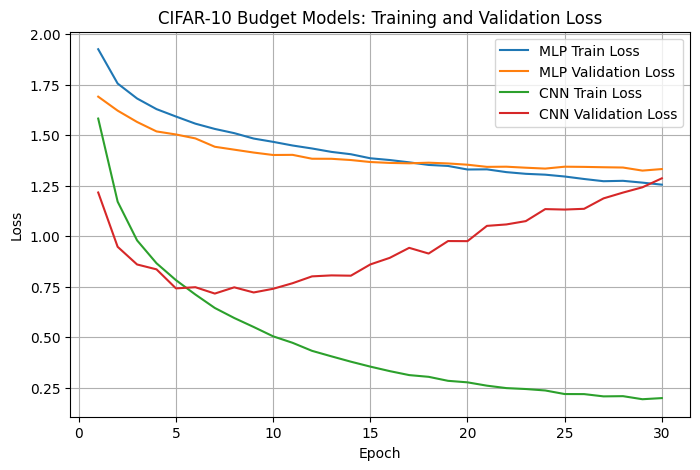

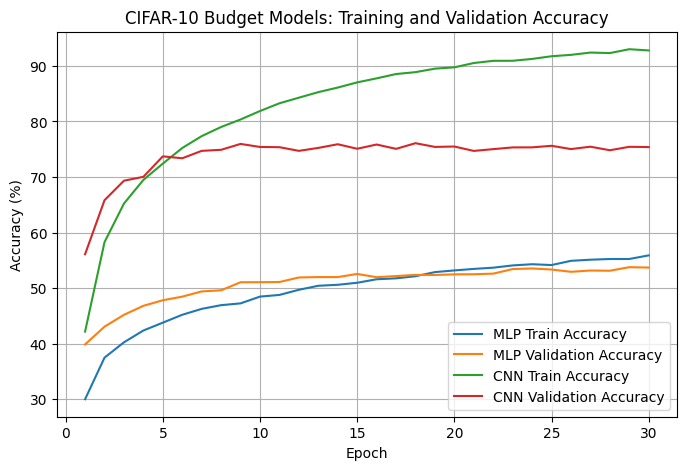

In [30]:
plot_loss_curves(
    budget_mlp_history,
    budget_cnn_history,
    "CIFAR-10 Budget Models"
)

plot_accuracy_curves(
    budget_mlp_history,
    budget_cnn_history,
    "CIFAR-10 Budget Models"
)

## B4.4. Part B Efficiency Analysis

Under the same parameter budget, the CNN performed substantially better than the MLP on CIFAR-10. The Budget MLP had 481,486 parameters and achieved 52.99% test accuracy, while the Budget CNN had 488,586 parameters and achieved 74.92% test accuracy. This is a 21.93 percentage point advantage for the CNN, showing that equal parameter counts do not imply equal usefulness.

The MLP’s parameters are concentrated in dense connections from the flattened image. Its first layer alone contains 405,504 parameters, because every input pixel position is connected to hidden units after flattening. This gives the MLP many parameters, but these parameters do not explicitly preserve local spatial relationships between neighbouring pixels.

The CNN uses its parameters more effectively because its convolutional layers learn local feature detectors for edges, textures, colours, and object parts. These filters are reused across spatial locations through weight sharing, giving the CNN a stronger inductive bias for image data. This helps it generalise better on CIFAR-10, where objects can appear in different positions and backgrounds.

However, the CNN was slower: it took 49.27 seconds per epoch, compared with 15.25 seconds per epoch for the MLP. This is because convolutional filters are repeatedly applied across many spatial positions. Therefore, similar parameter counts can still produce very different computational costs.


## B4.5. Part B Reflection

A structural modification that could improve the MLP is a patch-based MLP. Instead of flattening the entire CIFAR-10 image into one long vector immediately, the image could first be divided into smaller local patches, such as 4×4 or 8×8 regions. Each patch would then be flattened separately and passed through an MLP-style projection before the patch representations are combined for classification.

This directly addresses the property identified in Part A: CIFAR-10 depends strongly on local spatial structure. By processing small patches first, pixels that are close together in the original image remain grouped together during the early stages of learning. This could help the model detect local edges, colour patterns, textures, and object parts before combining those patch-level features into a global class prediction.

This is still not a convolutional layer because it does not use a small sliding kernel that moves across the image to produce feature maps. It also does not necessarily share the same local filter weights across all overlapping spatial positions in the way a convolution does. Instead, it uses dense transformations on fixed patch vectors. Therefore, it introduces spatial structure into the MLP while stopping short of true convolution.


# 6. Final Reproducibility Checklist

Before submission, I verified that:

- The notebook runs from top to bottom using Run All.
- Random seeds are set.
- MNIST and CIFAR-10 use standard test splits.
- Training data is split into 80% training and 20% validation.
- MNIST is resized to 32×32.
- Part A uses fixed core architectures across datasets.
- Part A includes all required result tables and plots.
- Part B models are within 475,000–525,000 parameters.
- Part B models are trained for at least 30 epochs.
- Training time and seconds per epoch are reported.
- Figures are rendered inline.
- No trained model weights are submitted.